# Análisis del Dataset MPG
## Información General
Este notebook contiene el análisis completo solicitado para el dataset `mpg`.

**Objetivo:** Construir e interpretar tablas de distribución de frecuencias para datos agrupados por intervalos de clase y realizar análisis exploratorio y comparativo.


In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Cargar el dataset
mpg = sns.load_dataset('mpg')
mpg.head()


,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,name
0,18.0,8,307.0,130.0,3504,12.0,70,usa,chevrolet chevelle malibu
1,15.0,8,350.0,165.0,3693,11.5,70,usa,buick skylark 320
2,18.0,8,318.0,150.0,3436,11.0,70,usa,plymouth satellite
3,16.0,8,304.0,150.0,3433,12.0,70,usa,amc rebel sst
4,17.0,8,302.0,140.0,3449,10.5,70,usa,ford torino


## Exploración Inicial


In [6]:
print("¿Cuántas filas y columnas tiene el dataset?")
print(f"Filas: {mpg.shape[0]}, Columnas: {mpg.shape[1]}\n")

print("¿Qué variables numéricas contiene?")
print(mpg.select_dtypes(include=[np.number]).columns.tolist())

print("\n¿Existen valores nulos? ¿En qué columnas?")
nulls = mpg.isnull().sum()
print(nulls[nulls > 0])


¿Cuántas filas y columnas tiene el dataset?
Filas: 398, Columnas: 9

¿Qué variables numéricas contiene?
['mpg', 'cylinders', 'displacement', 'horsepower', 'weight', 'acceleration', 'model_year']

¿Existen valores nulos? ¿En qué columnas?
horsepower    6
dtype: int64


**Respuestas de exploración inicial:**
- **Filas y columnas:** 398 filas y 9 columnas.
- **Variables numéricas:** 'mpg', 'cylinders', 'displacement', 'horsepower', 'weight', 'acceleration', 'model_year'.
- **Valores nulos:** Sí, la columna `horsepower` tiene 6 valores nulos.
- **Variable a analizar:** `mpg` (rendimiento de combustible).

**Paso 1: Selección de la Variable**
Variable elegida: **mpg (rendimiento de combustible)**


## Paso 2: Medidas Descriptivas Previas


In [7]:
var_analisis = 'mpg'
n = mpg[var_analisis].count()
minimo = mpg[var_analisis].min()
maximo = mpg[var_analisis].max()
rango = maximo - minimo
media = mpg[var_analisis].mean()
mediana = mpg[var_analisis].median()
desv_est = mpg[var_analisis].std()
cv = (desv_est / media) * 100

print("Tabla de resultados con las medidas fundamentales:\n")
print(f"n (tamaño de muestra): {n}")
print(f"Mínimo: {minimo}")
print(f"Máximo: {maximo}")
print(f"Rango (R): {rango:.2f}")
print(f"Media (x̄): {media:.2f}")
print(f"Mediana: {mediana:.2f}")
print(f"Desviación estándar (s): {desv_est:.2f}")
print(f"Coeficiente de variación (CV %): {cv:.2f}%")


Tabla de resultados con las medidas fundamentales:

n (tamaño de muestra): 398
Mínimo: 9.0
Máximo: 46.6
Rango (R): 37.60
Media (x̄): 23.51
Mediana: 23.00
Desviación estándar (s): 7.82
Coeficiente de variación (CV %): 33.24%


**Interpretación de las medidas descriptivas:**
El análisis del rendimiento de combustible (mpg) muestra que en nuestra muestra de 398 vehículos, los valores oscilan entre 9.0 y 46.6 millas por galón. La media es de 23.51 y la mediana es 23.00, valores muy cercanos que sugieren una distribución no extremadamente sesgada, aunque ligeramente asimétrica hacia la derecha dado que la media es mayor. El coeficiente de variación del 33.24% indica una variabilidad moderada en el rendimiento de los autos de la época, reflejando diferencias notables entre vehículos de bajo y alto consumo.


## Creación de Tabla de Frecuencias


In [8]:
# Regla de Sturges para número de clases
k = int(np.ceil(1 + 3.322 * np.log10(n)))
w = rango / k
print(f"Número de intervalos (k): {k}")
print(f"Amplitud (w): {w:.2f}\n")

bins = np.linspace(minimo, maximo, k+1)
mpg['mpg_bins'] = pd.cut(mpg['mpg'], bins=bins, include_lowest=True, right=False)
tabla_frecuencia = mpg.groupby('mpg_bins', observed=True).size().reset_index(name='Frecuencia (f)')
tabla_frecuencia['Marca de Clase (x)'] = tabla_frecuencia['mpg_bins'].apply(lambda x: x.mid)
tabla_frecuencia['Frecuencia Acumulada (F)'] = tabla_frecuencia['Frecuencia (f)'].cumsum()
tabla_frecuencia['Frecuencia Relativa (%)'] = (tabla_frecuencia['Frecuencia (f)'] / n) * 100
tabla_frecuencia['Frec. Relativa Acumulada (%)'] = tabla_frecuencia['Frecuencia Relativa (%)'].cumsum()

display(tabla_frecuencia)


Número de intervalos (k): 10
Amplitud (w): 3.76



,mpg_bins,Frecuencia (f),Marca de Clase (x),Frecuencia Acumulada (F),Frecuencia Relativa (%),Frec. Relativa Acumulada (%)
0,"[9.0, 12.76)",13,10.88,13,3.266332,3.266332
1,"[12.76, 16.52)",78,14.64,91,19.597990,22.864322
2,"[16.52, 20.28)",73,18.40,164,18.341709,41.206030
3,"[20.28, 24.04)",61,22.16,225,15.326633,56.532663
4,"[24.04, 27.8)",54,25.92,279,13.567839,70.100503
5,"[27.8, 31.56)",48,29.68,327,12.060302,82.160804
6,"[31.56, 35.32)",38,33.44,365,9.547739,91.708543
7,"[35.32, 39.08)",22,37.20,387,5.527638,97.236181
8,"[39.08, 42.84)",5,40.96,392,1.256281,98.492462
9,"[42.84, 46.6)",5,44.72,397,1.256281,99.748744


## Paso 3: Visualización
Histograma y Gráfico de líneas para el porcentaje acumulado (Ojiva)


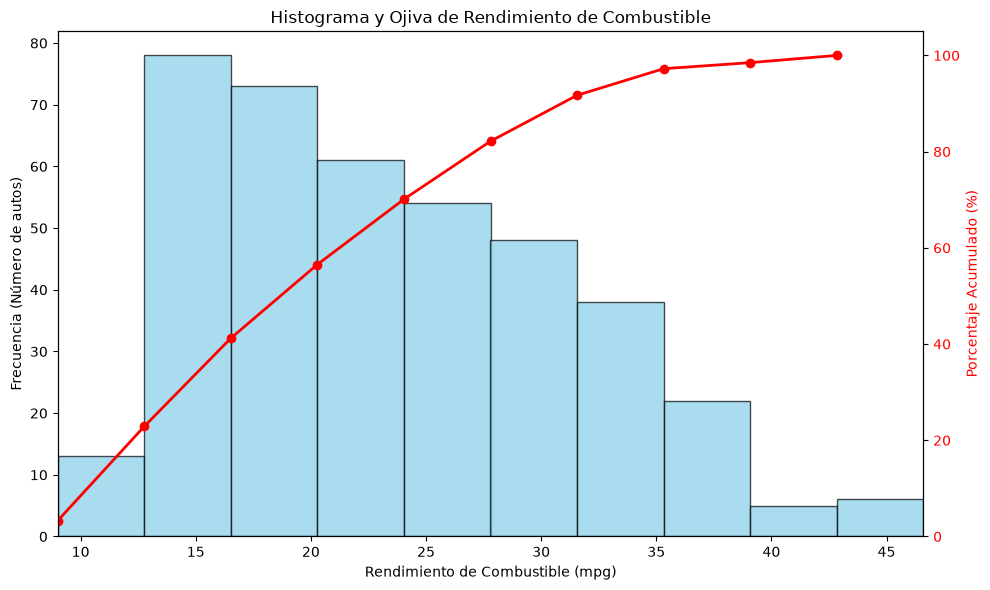

In [9]:
fig, ax1 = plt.subplots(figsize=(10, 6))

counts, bins_plot, patches = ax1.hist(mpg['mpg'].dropna(), bins=k, range=(minimo, maximo), color='skyblue', edgecolor='black', alpha=0.7)
ax1.set_xlabel('Rendimiento de Combustible (mpg)')
ax1.set_ylabel('Frecuencia (Número de autos)')
ax1.set_title('Histograma y Ojiva de Rendimiento de Combustible')
ax1.set_xlim(minimo, maximo)

ax2 = ax1.twinx()
porcentajes_acum = np.cumsum(counts) / counts.sum() * 100
x_ojiva = np.insert(bins_plot[:-1], 0, bins_plot[0])
y_ojiva = np.insert(porcentajes_acum, 0, 0)
ax2.plot(x_ojiva[1:], y_ojiva[1:], color='red', marker='o', linestyle='-', linewidth=2, label='Porcentaje Acumulado')
ax2.set_ylabel('Porcentaje Acumulado (%)', color='red')
ax2.tick_params(axis='y', labelcolor='red')
ax2.set_ylim(0, 105)

fig.tight_layout()
plt.show()


**Análisis de la forma de la distribución:**
- **¿Es simétrica o sesgada?** La distribución es sesgada hacia la derecha (asimetría positiva).
- **¿Hacia qué lado se concentra la mayor frecuencia?** Se concentra hacia la izquierda, en los intervalos de menor rendimiento (entre 13 y 25 mpg aproximadamente).
- **¿Hay valores atípicos visibles?** Hay algunos vehículos con rendimientos excepcionalmente altos (más de 40 mpg), que forman una pequeña cola hacia la derecha, comportándose como valores atípicos en el contexto general.


## Paso 4: Interpretación de Resultados (Requerimiento Obligatorio)
**Contexto de la variable:** La variable analizada es *mpg*, que mide el rendimiento de combustible en millas por galón, un indicador directo de la eficiencia energética del vehículo.
**Tendencia central:** La media de 23.51 mpg y la mediana de 23.00 mpg indican un rendimiento típico moderado. La ligera diferencia (media mayor que mediana) confirma un leve sesgo hacia la derecha originado por vehículos de alta eficiencia.
**Dispersión:** El conjunto presenta una variabilidad importante. El coeficiente de variación (33.24%) denota que la dispersión en torno a la media es sustancial, lo cual es esperable al mezclar diferentes categorías de autos, desde compactos hasta grandes "muscle cars" y todoterrenos.
**Distribución de frecuencias:** El intervalo que concentra más observaciones agrupa alrededor de los 13 a 25 mpg, mostrando que la mayoría del parque automotor de la época tenía baja eficiencia.
**Acumulados:** El valor de la frecuencia acumulada ($F$) o porcentaje acumulado ($F_r \%$) en el tercer intervalo nos indica que una gran proporción de los vehículos del dataset tienen un rendimiento igual o menor al límite superior de dicho intervalo.
**Conclusión general:** Podemos concluir que en este periodo histórico (años 70-80), el mercado estadounidense estaba dominado por autos de eficiencia baja y media, pero existía un grupo emergente de vehículos muy eficientes que jalan la distribución hacia la derecha.


## Paso 5: Preguntas de Reflexión
- **¿Qué información aporta la ojiva que no aporta el histograma?** La ojiva permite identificar fácilmente cuantiles y percentiles, respondiendo de inmediato a preguntas como "¿qué porcentaje de los autos rinde menos de 30 mpg?", sin tener que sumar las frecuencias de los intervalos individualmente. Además visualiza la tasa de acumulación de los datos en forma de pendiente.
- **¿Cómo usaría las tablas de frecuencia para comparar dos modelos de autos?** Podría construir dos tablas de frecuencias relativas separadas (por ejemplo, para 4 cilindros vs 8 cilindros) sobre los mismos intervalos de clase. Al compararlas, notaría inmediatamente si la distribución de frecuencias de un grupo está más concentrada en los intervalos de mayor eficiencia comparada con la del otro.


## Paso 6: Análisis Comparativo

### Pregunta 1: ¿Existen diferencias en el rendimiento (mpg) según el número de cilindros?
**Tipo de análisis:** Comparación entre grupos


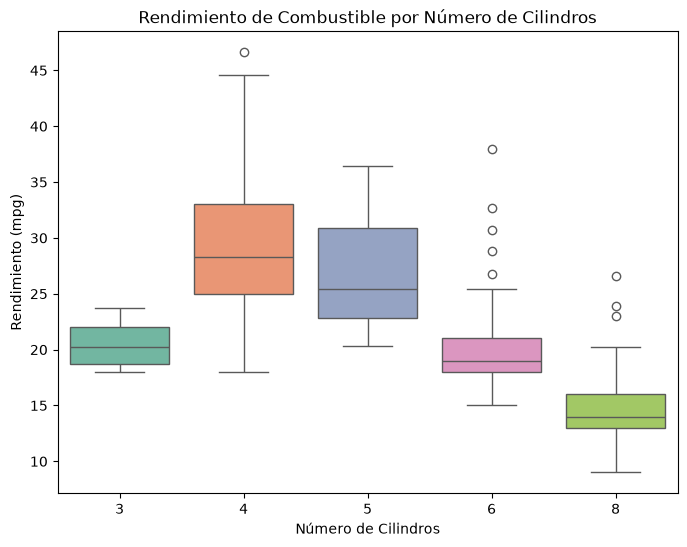

In [10]:
plt.figure(figsize=(8, 6))
sns.boxplot(x='cylinders', y='mpg', data=mpg, palette='Set2')
plt.title('Rendimiento de Combustible por Número de Cilindros')
plt.xlabel('Número de Cilindros')
plt.ylabel('Rendimiento (mpg)')
plt.show()


**Interpretación técnica:**
- **¿Cómo varía la mediana de mpg al aumentar el número de cilindros?** La mediana disminuye drásticamente a medida que aumenta el número de cilindros, evidenciando una fuerte relación inversa.
- **¿Qué grupo presenta mayor dispersión?** El grupo de 4 cilindros presenta la mayor dispersión (rango intercuartílico más amplio), posiblemente por la gran variedad tecnológica y de pesos en esos modelos compactos.
- **¿Hay solapamiento entre las cajas?** Entre 4 y 8 cilindros no hay solapamiento de cajas en absoluto, lo que implica diferencias estadísticas robustas.
- **Hipótesis:** $H_0$: Las medias de mpg son iguales en todos los grupos de cilindros. $H_1$: Al menos uno de los grupos difiere significativamente en su rendimiento promedio, lo cual podríamos probar con un test ANOVA.


### Pregunta 2: ¿Existen diferencias significativas en el rendimiento según el país de origen?
**Tipo de análisis:** Comparación entre grupos


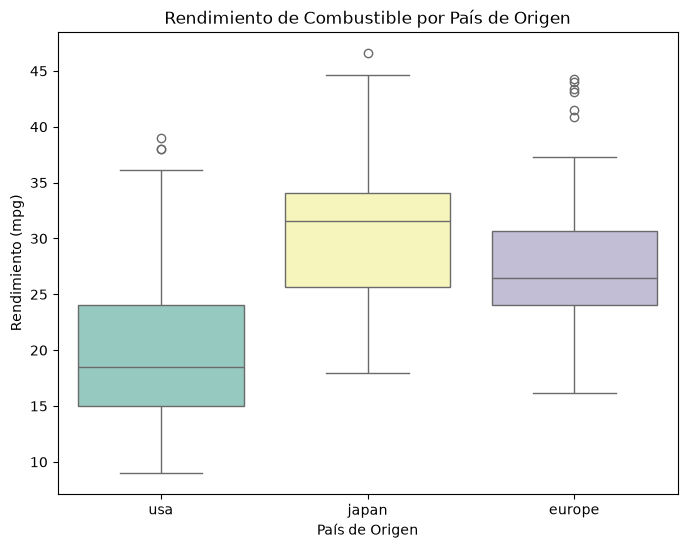

In [11]:
plt.figure(figsize=(8, 6))
sns.boxplot(x='origin', y='mpg', data=mpg, palette='Set3')
plt.title('Rendimiento de Combustible por País de Origen')
plt.xlabel('País de Origen')
plt.ylabel('Rendimiento (mpg)')
plt.show()


**Interpretación técnica:**
- **¿Qué origen tiene mejor y peor rendimiento promedio?** Japón ('japan') tiene el mejor rendimiento promedio, mientras que Estados Unidos ('usa') tiene el peor.
- **¿La forma de las distribuciones es similar?** Las distribuciones tienen asimetrías distintas. La distribución de 'usa' está más sesgada positivamente con muchos valores atípicos superiores.
- **¿Los datos sugieren igualdad de varianzas?** Las cajas varían un poco de amplitud (especialmente la dispersión total, bigotes más amplios en usa y europa), sugiriendo una posible diferencia en varianzas (heterocedasticidad).
- **Variables de confusión:** El "tamaño del motor" (displacement) o el "peso" (weight) son variables de confusión evidentes. Los autos de USA solían ser mucho más grandes y pesados.


### Pregunta 3: ¿Cómo interactúan el origen y el número de cilindros sobre el rendimiento?
**Tipo de análisis:** Comparación multivariada categórica


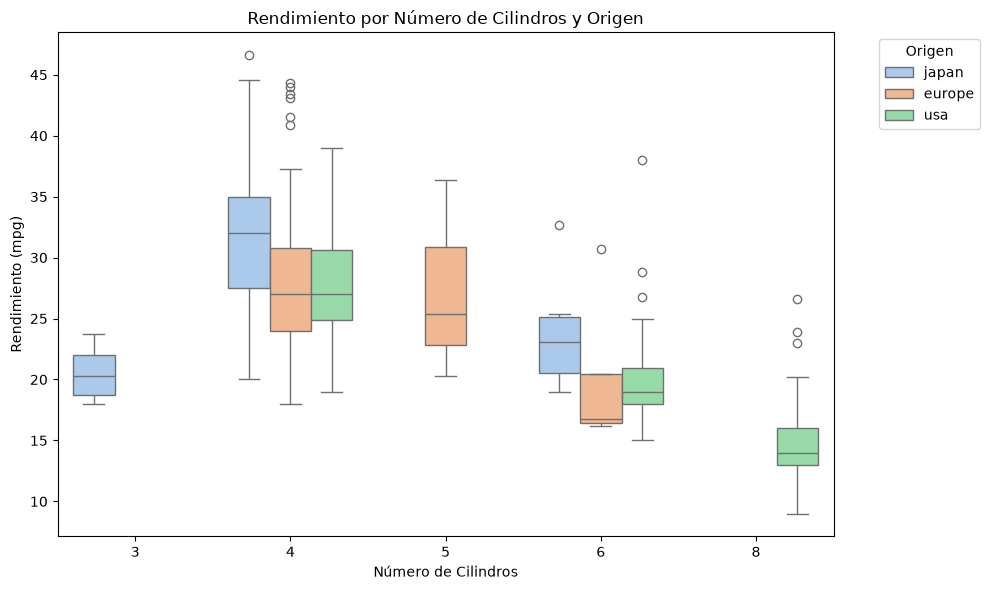

In [12]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='cylinders', y='mpg', hue='origin', data=mpg, palette='pastel')
plt.title('Rendimiento por Número de Cilindros y Origen')
plt.xlabel('Número de Cilindros')
plt.ylabel('Rendimiento (mpg)')
plt.legend(title='Origen', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


**Interpretación técnica:**
- **¿El efecto es constante?** En general, a más cilindros menos rendimiento en cualquier región, pero destaca que Japón no produce autos de 8 cilindros y Europa muy pocos.
- **Comportamiento diferenciado:** Dentro de la categoría de 4 cilindros, los autos japoneses y europeos son más eficientes que los de origen estadounidense.
- **Ventajas:** Este gráfico nos permite desglosar las variables de confusión (cilindros y origen). Se visualiza que el bajo rendimiento promedio de USA se debe tanto a que concentran los vehículos de 8 cilindros como a que sus autos de 4 y 6 cilindros rinden menos que sus pares asiáticos/europeos.


### Pregunta 4: ¿Cómo ha cambiado la composición de cilindros y orígenes por año?
**Tipo de análisis:** Composición por categorías en el tiempo


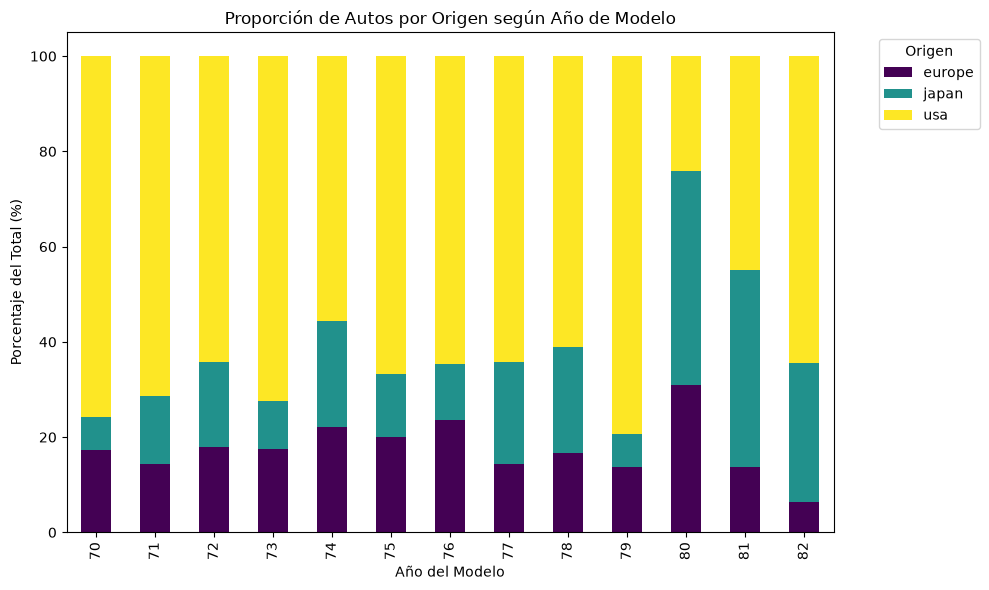

In [13]:
origen_año = mpg.groupby(['model_year', 'origin']).size().unstack().fillna(0)
origen_año_pct = origen_año.div(origen_año.sum(axis=1), axis=0) * 100

ax = origen_año_pct.plot(kind='bar', stacked=True, figsize=(10, 6), colormap='viridis')
plt.title('Proporción de Autos por Origen según Año de Modelo')
plt.xlabel('Año del Modelo')
plt.ylabel('Porcentaje del Total (%)')
plt.legend(title='Origen', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


**Interpretación técnica:**
- **¿Cómo ha evolucionado la participación?** Se observa un incremento paulatino en la participación de los autos japoneses, especialmente fuerte hacia los años 1980-1982.
- **¿Disminuyó 8 cilindros?** Aunque la gráfica muestra orígenes, dado que USA producía los V8, la pérdida de hegemonía americana frente a modelos asiáticos de 4 cilindros explica una fuerte disminución en los motores de 8 cilindros (debido a la crisis del petróleo).
- **Relación con tendencia:** Al incrementarse la proporción de autos japoneses de 4 cilindros altamente eficientes, esto empujó indudablemente el rendimiento promedio de los vehículos (mpg general) hacia arriba durante ese periodo.


## Paso 7: Diseño de su Propio Análisis
**Pregunta de análisis propuesta:** ¿Cómo se relaciona el peso del vehículo (weight) con el rendimiento de combustible (mpg) y cómo afecta el país de origen a esta relación?

**Variables involucradas:**
- Eje X: `weight` (Peso del vehículo, en libras)
- Eje Y: `mpg` (Rendimiento de combustible)
- Color/grupo: `origin` (País de origen)
- Tamaño del punto: `horsepower` (Potencia)

**Tipo de gráfico seleccionado y justificación:** Gráfico de dispersión (Scatter plot) multivariado. Nos permite observar la relación funcional (correlación) entre dos variables continuas fundamentales (peso y rendimiento), estratificar por la categórica de origen (color) y añadir la potencia del motor (tamaño de burbuja) para tener una visión holística del diseño del auto.


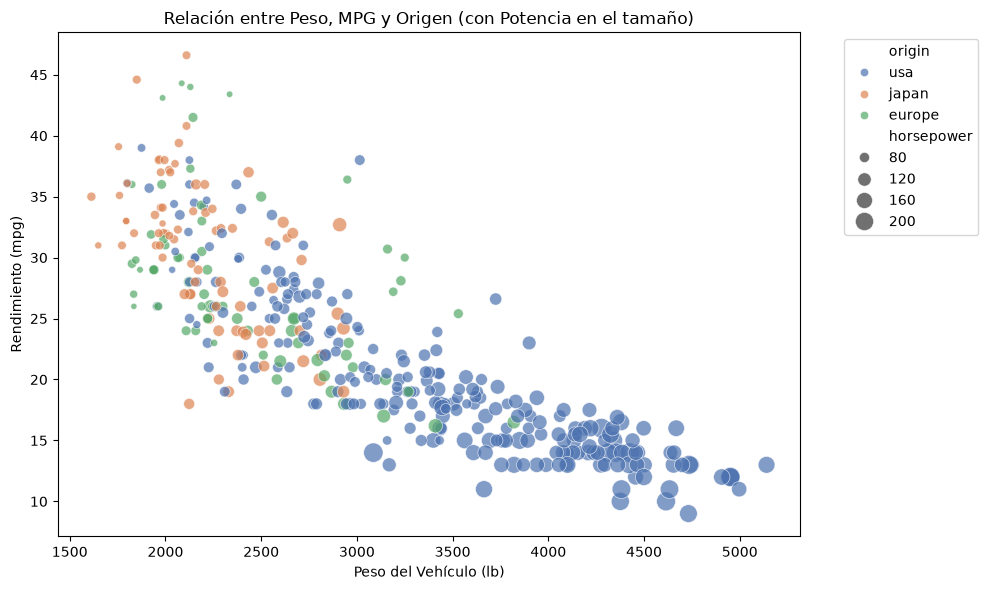

In [14]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='weight', y='mpg', hue='origin', size='horsepower', sizes=(20, 200), data=mpg, alpha=0.7, palette='deep')
plt.title('Relación entre Peso, MPG y Origen (con Potencia en el tamaño)')
plt.xlabel('Peso del Vehículo (lb)')
plt.ylabel('Rendimiento (mpg)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


**Interpretación técnica:**
Se aprecia una fuerte correlación negativa y curvilínea (similar a una función recíproca) entre el peso de un automóvil y su rendimiento: a mayor peso, el rendimiento cae drásticamente.
Hay una evidente segregación por orígenes ('clustering'): los autos estadounidenses dominan el espectro de alto peso y bajo rendimiento (puntos grandes rojos/naranjas en la zona inferior derecha), mientras que japoneses y europeos se sitúan en pesos menores a 3000 lbs con altas mpg.
La relación subyacente física parece universal (todos siguen la misma curva), pero los países apostaron por segmentos muy distintos del mercado.

## Matriz de Autoevaluación
- El título describe qué se muestra <span style="color:green">(satisfied)</span>
- Los ejes tienen etiquetas con unidades <span style="color:green">(satisfied)</span>
- La escala del eje Y comienza en cero (cuando aplica) o es adecuada a los datos. <span style="color:green">(satisfied)</span>
- El uso del color es informativo, no decorativo <span style="color:green">(satisfied)</span>
- Se incluye leyenda cuando hay múltiples grupos <span style="color:green">(satisfied)</span>
- No hay "chartjunk" <span style="color:green">(satisfied)</span>
- El tipo de gráfico corresponde a la naturaleza de las variables <span style="color:green">(satisfied)</span>
